Processing Image Size: 61x61 pixels
Running 5D Mean Shift Segmentation (this may take a moment)...
Iteration 1/5
Iteration 2/5
Iteration 3/5
Iteration 4/5
Iteration 5/5
Mean Shift completed in 5.91 seconds.
Clustering modes...
Total clusters found: 127


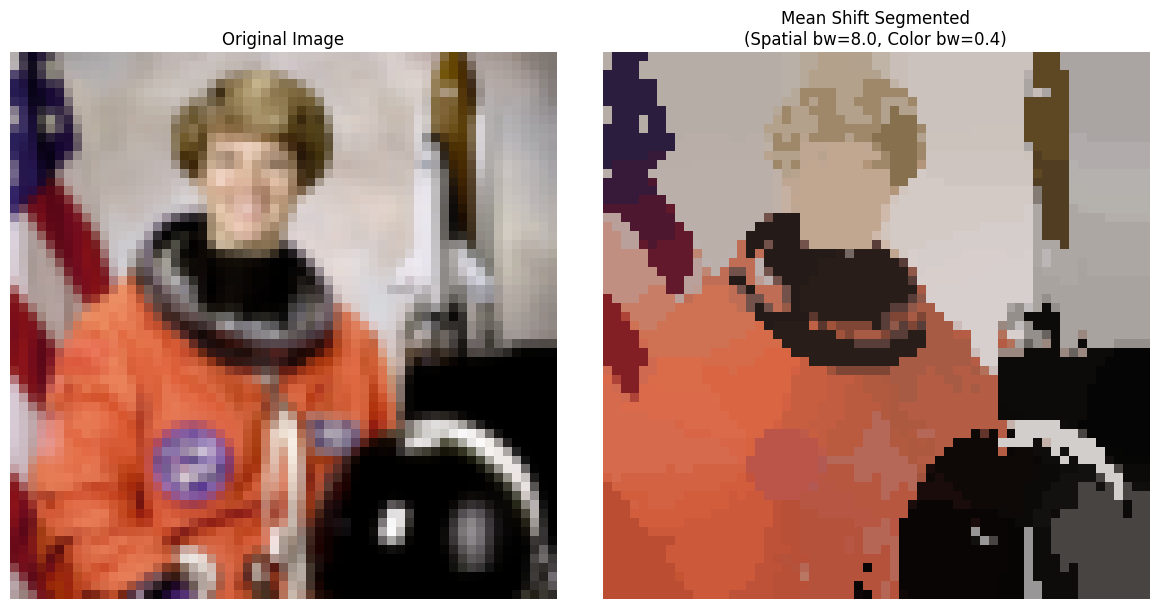

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform
from skimage.util import img_as_float
import time

# 1. Load Image & Preprocessing

img = data.astronaut() 

scale_percent = 0.12 # Resize to roughly 60x60 pixels
img = transform.rescale(img, scale_percent, channel_axis=2, anti_aliasing=True)

img = img_as_float(img) # Convert to double (0.0 to 1.0)
rows, cols, ch = img.shape
print(f"Processing Image Size: {rows}x{cols} pixels")

yy, xx = np.meshgrid(np.arange(rows), np.arange(cols), indexing='ij')

# 2. Create 5D feature vector: [x y R G B]

# Flatten arrays
flat_x = xx.reshape(-1, 1)
flat_y = yy.reshape(-1, 1)
flat_rgb = img.reshape(-1, 3)

# Combine into N x 5 matrix
features = np.hstack((flat_x, flat_y, flat_rgb))

# Number of pixels
N = features.shape[0]

# 3. Mean Shift Parameters

hs = 8.0       # Spatial bandwidth (pixels)
hr = 0.4       # Color bandwidth (0.0 to 1.0 range for float images)
max_iters = 5  # Reduced iterations for speed in notebook
epsilon = 1e-3 # Convergence threshold

# Start modes at original feature positions
modes = features.copy()

print("Running 5D Mean Shift Segmentation (this may take a moment)...")
start_time = time.time()

# 4. Mean Shift Iterations

for iteration in range(max_iters):
    print(f"Iteration {iteration + 1}/{max_iters}")
    
    max_shift_iter = 0.0
    
    
    
    for i in range(N):
        cur_point = modes[i, :]
        
        
        # 1. Compute Spatial Distance 
        spatial_dists = np.linalg.norm(features[:, :2] - cur_point[:2], axis=1)
        
        # 2. Compute Color Distance (Euclidean on R,G,B only)
        color_dists = np.linalg.norm(features[:, 2:] - cur_point[2:], axis=1)
        
        # 3. Find neighbors within spatial AND color bandwidths
        mask = (spatial_dists < hs) & (color_dists < hr)
        
        # Get neighbors
        neighbors = features[mask]
        
        # 4. Compute Mean Shift
        if len(neighbors) > 0:
            new_point = np.mean(neighbors, axis=0)
        else:
            new_point = cur_point
            
        # Shift magnitude
        shift = np.linalg.norm(new_point - cur_point)
        
        # Update mode
        modes[i, :] = new_point
        
        if shift > max_shift_iter:
            max_shift_iter = shift

    # Global convergence check
    if max_shift_iter < epsilon:
        print("Converged early.")
        break

print(f"Mean Shift completed in {time.time() - start_time:.2f} seconds.")

# 5. Cluster pixels whose modes converge close together

print("Clustering modes...")

cluster_labels = np.zeros(N, dtype=int)
cluster_count = 0
modes_final = [] # List to store unique cluster centers



for i in range(N):
    assigned = False
    current_mode = modes[i, :]
    
    # Check against existing found clusters
    for j in range(cluster_count):
        # Distance between current mode and existing cluster center
        dist = np.linalg.norm(current_mode - modes_final[j])
        
        if dist < 3.0: 
            cluster_labels[i] = j
            assigned = True
            break
            
    if not assigned:
        modes_final.append(current_mode)
        cluster_labels[i] = cluster_count
        cluster_count += 1

# Convert list to array for easier indexing later
modes_final = np.array(modes_final)

print(f"Total clusters found: {cluster_count}")

# 6. Construct segmented image from cluster modes

seg_img_flat = np.zeros((N, 3))

for k in range(cluster_count):
    
    seg_img_flat[cluster_labels == k, :] = modes_final[k, 2:]

seg_img = seg_img_flat.reshape(rows, cols, 3)

# 7. Display Original and Segmented Images

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(seg_img)
plt.title(f'Mean Shift Segmented\n(Spatial bw={hs}, Color bw={hr})')
plt.axis('off')

plt.tight_layout()
plt.show()